# Create a Simple Reflex-Based Lunar Lander Agent

In this example, we will use Gymnasium, an environment to train agents via reinforcement learning (RL). We will not use RL here but just use the environment with a custom simple reflex-based agent.

## Install Gymnasium

The documentation for Gymnasium is available at https://gymnasium.farama.org/

Steps:
1. Create a new folder and open it with VS Code and install all needed Python Extensions in VS Code.
2. Create a new virtual environment (CTRL-Shift P Python Create Environment...)
3. I needed to install swig and the Python C++ headers on WSL2 via the terminal
    * `sudo apt install swig`
    * `sudo apt-get install python3-dev`
4. Install python libraries for gymnasium with the needed extras

In [1]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "swig>=4,<5" "gymnasium[box2d,classic-control]>=1.0,<2"

Additional installs for screen capturing so environment visualizations can be converted to embedded videos.
For recording videos, I had to install
    
* `sudo apt-get install xvfb ffmpeg`

Additional python packages for screen capturing.

In [2]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "pyvirtualdisplay>=3,<4" "gymnasium[other]>=1.0,<2"

## The Lunar Lander Environment

![Luna Lander image](https://gymnasium.farama.org/_images/lunar_lander.gif)

The documentation of the environment is available at: https://gymnasium.farama.org/environments/box2d/lunar_lander/

* Performance Measure: A reward of -100 or +100 points for crashing or landing safely respectively. We do not use
  intermediate rewards here.

* Environment: This environment is a classic rocket trajectory optimization problem. A ship needs to land safely. The space is **continuous** with
  x and y coordinates in the range [-2.5, 2.5]. The landing pad is at coordinate (0,0).

* Actuators:  According to Pontryagin’s
  maximum principle, it is optimal to fire the engine at full throttle or turn it off. This is the reason why this environment has discrete actions: engine on or off. There are four discrete actions available:

    - 0: do nothing
    - 1: fire left orientation engine
    - 2: fire main engine
    - 3: fire right orientation engine

* Sensors: Each observation is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

The different ranges/settings of the environment can be queried.

In [3]:
import gymnasium as gym
import numpy as np
np.set_printoptions(precision=2)

In [4]:
def query_environment(name):
    env = gym.make(name)
    print(f"Action Space: {env.action_space}")
    print(f"Observation Space: {env.observation_space}")
    print(f"Max Episode Steps: {env.spec.max_episode_steps}")
    print(f"Nondeterministic: {env.spec.nondeterministic}")
   # print(f"Reward Range: {env.reward_range}")
    print(f"Reward Threshold: {env.spec.reward_threshold}")
    env.close()

query_environment("LunarLander-v3")

Action Space: Discrete(4)
Observation Space: Box([ -2.5   -2.5  -10.   -10.    -6.28 -10.    -0.    -0.  ], [ 2.5   2.5  10.   10.    6.28 10.    1.    1.  ], (8,), float32)
Max Episode Steps: 1000
Nondeterministic: False
Reward Threshold: 200



Gymnasium environments are implemented as classes with a `make` method to create the environment, a `reset` method, and a `step` method to execute an action.
To use it with an agent function that expects percepts and returns an action, we need write glue code that connects the environment with the agent function.

In [5]:
def run_episode(agent_function, env, max_steps=1000, verbose = True, render = True):
    """Run one episode in the environment using the provided agent."""

    # Reset the environment to generate the first observation (use seed=42 in reset to get reproducible results)
    observation, info = env.reset()

    # run one episode
    for _ in range(max_steps):
        # call the agent function to select an action
        action = agent_function(observation)

        if verbose:
            print (f"Obs: {observation} -> Action: {action}")

        # step: execute an action in the environment
        observation, reward, terminated, truncated, info = env.step(action)

        # render the environment
        if render:
            env.render()

        if terminated:
            if verbose:
                print(f"Final Reward: {reward}")
            break

    return reward

## Example: A Random Agent

We randomly return one of the actions. The environment accepts the integers 0-3.


In [6]:
def random_agent_function(observation):
    """A random agent that selects actions uniformly at random. It ignores the observation."""
    return np.random.choice([0, 1, 2, 3], p=[0.25, 0.25, 0.25, 0.25])

Run an episode.

In [7]:
env = gym.make("LunarLander-v3", render_mode="human")

run_episode(random_agent_function, env)

env.close()

Obs: [ 0.    1.42  0.25  0.27 -0.   -0.06  0.    0.  ] -> Action: 2
Obs: [ 0.01  1.42  0.26  0.28 -0.01 -0.05  0.    0.  ] -> Action: 2
Obs: [ 0.01  1.43  0.25  0.31 -0.01 -0.06  0.    0.  ] -> Action: 0
Obs: [ 0.01  1.44  0.25  0.28 -0.01 -0.06  0.    0.  ] -> Action: 1
Obs: [ 0.01  1.44  0.23  0.26 -0.01 -0.02  0.    0.  ] -> Action: 3
Obs: [ 0.01  1.45  0.25  0.23 -0.02 -0.07  0.    0.  ] -> Action: 3
Obs: [ 0.02  1.45  0.25  0.21 -0.02 -0.1   0.    0.  ] -> Action: 2
Obs: [ 0.02  1.46  0.25  0.21 -0.03 -0.11  0.    0.  ] -> Action: 3
Obs: [ 0.02  1.46  0.25  0.18 -0.03 -0.15  0.    0.  ] -> Action: 0
Obs: [ 0.02  1.46  0.25  0.15 -0.04 -0.15  0.    0.  ] -> Action: 3
Obs: [ 0.03  1.47  0.27  0.13 -0.05 -0.19  0.    0.  ] -> Action: 0
Obs: [ 0.03  1.47  0.27  0.1  -0.06 -0.19  0.    0.  ] -> Action: 0
Obs: [ 0.03  1.47  0.27  0.07 -0.07 -0.19  0.    0.  ] -> Action: 0
Obs: [ 0.03  1.47  0.27  0.05 -0.08 -0.19  0.    0.  ] -> Action: 0
Obs: [ 0.04  1.47  0.27  0.02 -0.09 -0.19  0.   

Gymnasium displays environments using `render()` method on the local display. Headless installations like Google Colab do not have a display, but the output can be captured using a virtual display as a video and then add the video to the notebook.

We need to start a virtual display.

Now we can use wrappers for the environment to record the display. The functions are provided in
[display_record.py].



In [8]:
# download if missing
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

download("gymnasium_display_recorder.py",
         "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Agents/")

In [9]:
# %pip install pyvirtualdisplay

In [10]:
import gymnasium_display_recorder as dr

# Install pyvirtualdisplay if not already installed
!pip install -q "pyvirtualdisplay>=3,<4" "gymnasium[other]>=1.0,<2"

env = dr.gym_make('LunarLander-v3', 'LL1', render_fps=30)
run_episode(random_agent_function, env, verbose=False)
env.close()

dr.show('LL1')

/usr/local/lib/python3.13/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


## A Simple Reflex-Based Agent

To make the code easier to read, we use enumerations for actions (integers) and observations (index in the observation vector).

In [11]:
from enum import Enum

class Act(Enum):
    LEFT = 1
    RIGHT = 3
    MAIN = 2
    NO_OP = 0

class Obs(Enum):
    X = 0
    Y = 1
    VX = 2
    VY = 3
    ANGLE = 4
    ANGULAR_VELOCITY = 5
    LEFT_LEG_CONTACT = 6
    RIGHT_LEG_CONTACT = 7


Define a simple agent that uses the main thruster to reduce the falling speed if it gets too fast.

In [12]:
def rocket_agent_function(observation):
    """A simple agent function."""

    # run the main thruster, if the lander is falling too fast
    if observation[Obs.VY.value] < -.4:
        return Act.MAIN.value

    return Act.NO_OP.value

In [13]:
env = dr.gym_make('LunarLander-v3', 'LL2', render_fps=30)
run_episode(rocket_agent_function, env, verbose = False)
env.close()

dr.show('LL2')

/usr/local/lib/python3.13/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


## Evaluating the Agent

Run the agent on 100 problems and report the average reward.

In [14]:
def run_episodes(agent_function, env, n=1000):
    """Run multiple episodes with the given agent and return the rewards for each episode."""
    return [run_episode(agent_function, env, verbose=False, render=False) for _ in range(n)]

Run experiments.

In [15]:
env = gym.make("LunarLander-v3", render_mode=None)

rewards = run_episodes(rocket_agent_function, env, n=100)
print(rewards)

print(f"Average reward: {np.average(rewards)}")
print(f"Success rate: {np.sum(np.array(rewards) == 100)}/{len(rewards)}")

[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]
Average reward: -100.0
Success rate: 0/100


In [16]:
env = gym.make("LunarLander-v3", render_mode=None)

rewards = run_episodes(rocket_agent_function, env, n=100)
print(rewards)

print(f"Average reward: {np.average(rewards)}")
print(f"Success rate: {np.sum(np.array(rewards) == 100)}/{len(rewards)}")

[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]
Average reward: -100.0
Success rate: 0/100


This is not great performance!


## Implement A Better Reflex-Based Agent

Build a better that uses its right and left thrusters to land the craft (more) safely. Test your agent function using 100 problems.

### 1. Tổng quan

Tác tử `better_reflex_agent_function` là một **tác tử phản xạ không trạng thái (stateless reflex agent)**.  
Mọi quyết định được đưa ra **chỉ dựa trên vector quan sát hiện tại** (8 chiều), không sử dụng thông tin từ các bước thời gian trước đó.
Khác với hai tác tử trước đó là chỉ hãm rơi theo trục dọc hoặc hành động ngẫu nhiên, tác tử cải tiến bổ sung thêm:

- Điều khiển tư thế (nghiêng trái/phải).
- Điều khiển vận tốc ngang để tiến về tâm bệ hạ cánh.
- Điều chỉnh tốc độ rơi theo độ cao.
### 2. Trạng thái bên trong

Đây vẫn là một tác tử Simple Reflex Agent, không có trạng thái bên trong.
- Hàm không duy trì biến toàn cục để lưu trữ quỹ đạo các bước trước đó.
- Tại mỗi bước thời gian $t$, hành động $A_t$ chỉ phụ thuộc duy nhất vào vector cảm biến tức thời $S_t$.
- Việc tác tử có thể tính toán được xu hướng thay đổi vị trí và độ nghiêng là nhờ môi trường mô phỏng Gymnasium đã cung cấp sẵn các đạo hàm bậc nhất theo thời gian (vận tốc tuyến tính $v_x, v_y$ và vận tốc góc $\omega$) ngay trong vector quan sát 8 chiều.

Khi môi trường `reset()`, tác tử không cần khởi tạo lại vì nó vốn không nhớ gì.

### 3. Chiến lược hoạt động

Tác tử chia việc điều khiển thành 3 tầng ưu tiên giảm dần.
1. **Điều hướng theo trục ngang (**$x, v_x$**):**

    * Tàu không có động cơ phản lực tịnh tiến ngang trực tiếp. Để di chuyển về bãi đáp tại tâm $x = 0$, tàu buộc phải tạo một góc nghiêng vừa phải.

        $$
        \theta_{\text{target}} = k_p \cdot x + k_d \cdot v_x
        $$

        Trong đó thành phần $k_p \cdot x$ kéo tàu về tâm, còn $k_d \cdot v_x$ đóng vai trò vận tốc ngang.

    * Giá trị góc được khống chế trong ngưỡng an toàn: khoảng $\pm 23^\circ$ nhằm tránh lật tàu.
2. **Kiểm soát góc nghiêng & chóng xoay (**$\theta, \omega$**):**
* Nếu thân tàu lệch góc hoặc đang tự quay nhanh, bật động cơ chính sẽ khiến tàu văng xa hoặc đâm đầu xuống đất. Do đó, việc cân bằng góc luôn được ưu tiên kiểm tra trước:

     * Nếu sai số góc $\theta - \theta_{\text{target}} > 0.05$ hoặc vận tốc góc $\omega > 0.1$ (đang nghiêng/xoay sang phải): Kích hoạt động cơ phụ phải để tạo mô-men xoắn xoay ngược về bên trái.

     * Nếu sai số góc $\theta - \theta_{\text{target}} < -0.05$ hoặc $\omega < -0.1$ (đang nghiêng/xoay sang trái): Kích hoạt động cơ phụ trái để xoay về bên phải.

3. **Hãm tốc độ rơi mềm theo độ cao (**$y, v_y$**):**
* Khi góc nghiêng đã nằm trong ngưỡng an toàn, tác tử kiểm soát vận tốc thẳng đứng $v_y$.

     * Khi còn ở trên cao: cho phép tàu rơi nhanh hơn chút

     * Khi gần sát mặt đất: giảm vẫn tốc xuống mức an toàn hơn để hạ tiếp đất êm

   * Nếu tốc độ rơi nhanh hơn ngưỡng an toàn, kích hoạt **động cơ chính (`MAIN`)** để phanh lại.

   * Ngược lại, giữ trạng thái **không làm gì (`NO_OP`)** để tiết kiệm nhiên liệu và tận dụng trọng lực hạ cánh.

In [17]:
def better_reflex_agent_function(observation):
    x = observation[Obs.X.value]
    y = observation[Obs.Y.value]
    vx = observation[Obs.VX.value]
    vy = observation[Obs.VY.value]
    angle = observation[Obs.ANGLE.value]
    w = observation[Obs.ANGULAR_VELOCITY.value]

    target_angle = x * 0.5 + vx * 1.0

    target_angle = np.clip(target_angle, -0.4, 0.4)

    angle_error = angle - target_angle
    if angle_error > 0.05 or w > 0.1:
        return Act.RIGHT.value
    elif angle_error < -0.05 or w < -0.1:
        return Act.LEFT.value

    target_vy = -0.3 if y > 0.5 else -0.15
    if vy < target_vy:
        return Act.MAIN.value

    return Act.NO_OP.value


In [18]:
env = gym.make("LunarLander-v3", render_mode=None)

rewards = run_episodes(better_reflex_agent_function, env, n=100)
print(rewards)

print(f"Average reward: {np.average(rewards)}")
print(f"Success rate: {np.sum(np.array(rewards) == 100)}/{len(rewards)}")

[-100, -100, -100, -100, -100, 100, -100, -100, -100, -100, -100, -100, 100, -100, -100, -100, -100, -100, 100, -100, -100, -100, 100, 100, 100, 100, -100, 100, -100, 100, -100, -100, -100, 100, -100, -100, 100, -100, -100, 100, -100, -100, -100, 100, -100, 100, -100, 100, -100, -100, -100, -100, 100, -100, -100, 100, -100, -100, 100, 100, -100, -100, -100, 100, -100, 100, 100, 100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 100, -100, 100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 100, -100, 100, 100, 100, -100, -100, 100]
Average reward: -40.0
Success rate: 30/100


## Bảng kết quả thực nghiệm của 3 tác tử (100 Episodes)

|  | 1. Random Agent | 2. Rocket Agent (Simple Reflex) | 3. Better Reflex Agent |
| :--- | :---: | :---: | :---: |
| **Điểm thưởng trung bình** | -100 | -100 | **-40** |
| **Tỷ lệ thành công (Success Rate)** | **0.0%** | **0.0%** | **30.0%** |

### Nhận xét kết quả thực nghiệm

* **Random Agent (Tác tử ngẫu nhiên):** Hoàn toàn mất kiểm soát do chọn hành động ngẫu nhiên, kết quả đạt chuẩn đáy với 0.0% tỷ lệ thành công và điểm thưởng trung bình -100.0.

* **Rocket Agent (Tác tử phản xạ cơ bản):** Chỉ dùng động cơ chính để hãm vận tốc rơi $v_y$ mà bỏ qua góc nghiêng và độ trôi ngang, khiến tàu vẫn bị lật hoặc văng xa bãi đáp, dẫn đến tỷ lệ thành công tiếp tục là 0.0% (-100.0 điểm)

* **Better Reflex Agent (Tác tử phản xạ cải tiến):** Nhờ phối hợp kiểm soát cả góc nghiêng, vị trí ngang và tốc độ rơi, hiệu năng tăng vọt lên 30.0% tỷ lệ thành công và điểm trung bình cải thiện rõ rệt lên -40.0

## Biểu đồ so sánh kết quả

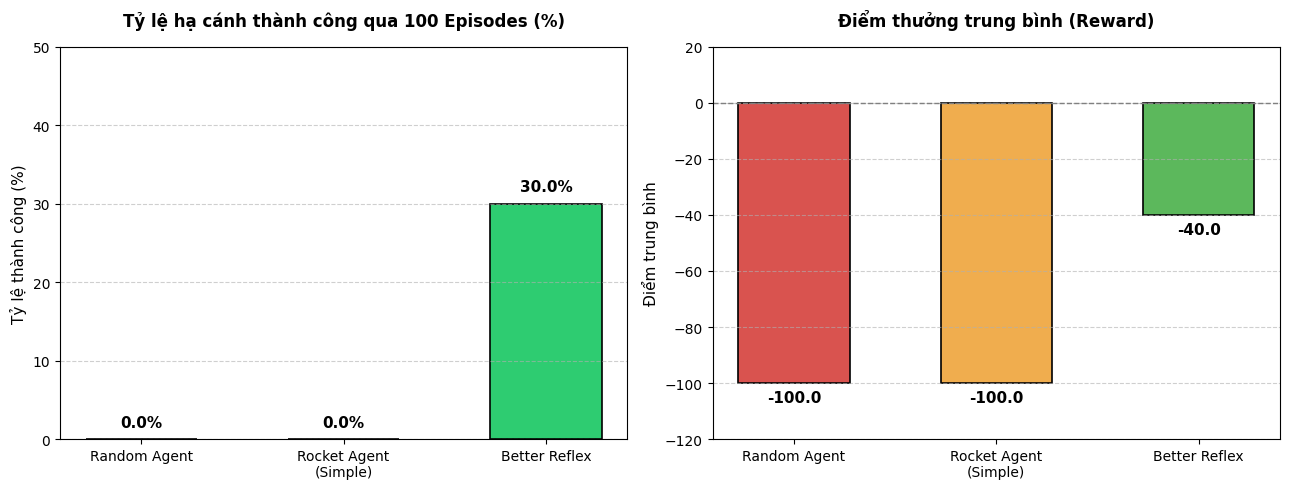

In [21]:
import matplotlib.pyplot as plt
import numpy as np

agents = ['Random Agent', 'Rocket Agent\n(Simple)', 'Better Reflex\n']
success_rates = [0.0, 0.0, 30.0]
avg_rewards = [-100.0, -100.0, -40.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 2. Biểu đồ 1: Tỷ lệ hạ cánh thành công (%)
colors_bar1 = ['#e74c3c', '#e67e22', '#2ecc71']
bars1 = ax1.bar(agents, success_rates, color=colors_bar1, width=0.55, edgecolor='black', linewidth=1.2)
ax1.set_title('Tỷ lệ hạ cánh thành công qua 100 Episodes (%)', fontsize=12, fontweight='bold', pad=15)
ax1.set_ylabel('Tỷ lệ thành công (%)', fontsize=11)
ax1.set_ylim(0, 50)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 1.2, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=11)

# 3. Biểu đồ 2: Điểm thưởng trung bình
colors_bar2 = ['#d9534f', '#f0ad4e', '#5cb85c']
bars2 = ax2.bar(agents, avg_rewards, color=colors_bar2, width=0.55, edgecolor='black', linewidth=1.2)
ax2.set_title('Điểm thưởng trung bình', fontsize=12, fontweight='bold', pad=15)
ax2.set_ylabel('Điểm trung bình', fontsize=11)
ax2.set_ylim(-120, 20)
ax2.axhline(0, color='gray', linewidth=1, linestyle='--')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + (3 if yval >= 0 else -8), f"{yval:.1f}", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## Kết luận

* **Cải thiện hiệu năng rõ rệt:** Việc nâng cấp từ tác tử ngẫu nhiên và phản xạ đơn biến sang tác tử phản xạ đa tham số (kết hợp cân bằng góc nghiêng $\theta, \omega$, kéo tàu về tâm $x = 0$ và hãm tốc độ rơi) đã giúp tỷ lệ hạ cánh thành công tăng từ **0.0% lên 30.0%**, điểm thưởng trung bình tăng từ **-100.0 lên -40.0**.
* **Giới hạn của tác tử phản xạ cục bộ:** Tỷ lệ thất bại 70.0% còn lại cho thấy tác tử phản xạ đơn thuần không thể làm chủ hoàn toàn môi trường vật lý liên tục do thiếu khả năng dự đoán tương lai, xung đột khi chỉ được chọn một động cơ rời rạc tại mỗi bước và độ nhạy trước các trạng thái khởi tạo ngẫu nhiên.
* **Hướng phát triển:** Để đạt hiệu quả tối ưu và độ ổn định cao, hệ thống cần được nâng cấp lên **Tác tử có mô hình (Model-Based Agent)** hoặc huấn luyện bằng các giải thuật **Học tăng cường sâu (Deep Reinforcement Learning)**.


&copy; 2025 [Michael Hahsler](https://michael.hahsler.net).
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)